## Overlaying for checking

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load data and select composition columns only

In [2]:
df_source_o = pd.read_csv('./data_common/df_source.csv')
df_GMM_o = pd.read_csv('./data_common/generated_samples_GMM.csv')
df_opt_def_o = pd.read_csv('./data_common/df_pareto_opt_comp_def.csv')
df_opt_gmm_o = pd.read_csv('./data_common/df_pareto_opt_comp_gmm.csv')

df_source = df_source_o.iloc[:, 2:9]
df_GMM = df_GMM_o.copy()
df_opt_def = df_opt_def_o.iloc[:, :7]
df_opt_gmm = df_opt_gmm_o.iloc[:, :7]

print(df_source.shape)
print(df_GMM.shape)
print(df_opt_def.shape)
print(df_opt_gmm.shape)

(594, 7)
(10002, 7)
(14, 7)
(12, 7)


## Comparison in elements

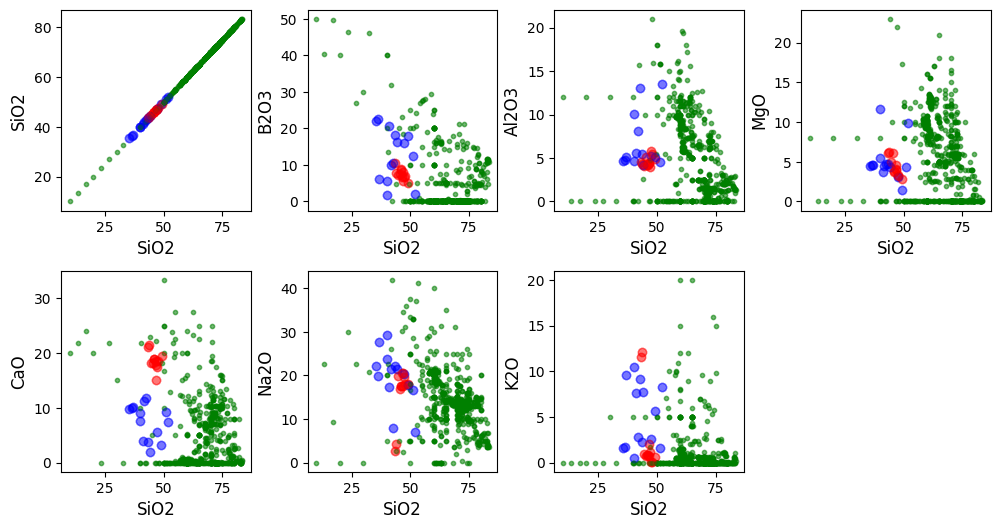

In [3]:
# Draw scatter plots by elements

horz = 4                     # vertical number of graph
vert = 2                     # horizontal number of graph
graph_num = horz * vert      # maximum number of graphs
axes = list()
fig = plt.figure(figsize=(12, 6))

for i in range(0, 7):
    axes.append(fig.add_subplot(vert, horz, i+1))

    for j in range(1, 8) :
        x_source = df_source.iloc[:, 0]
        y_source = df_source.iloc[:, i]
        x_gmm = df_GMM.iloc[:, 0]
        y_gmm = df_GMM.iloc[:, i]
        x_pareto_def = df_opt_def.iloc[:, 0]
        y_pareto_def = df_opt_def.iloc[:, i]
        x_pareto_gmm = df_opt_gmm.iloc[:, 0]
        y_pareto_gmm = df_opt_gmm.iloc[:, i]
        
        axes[i].scatter(x_source, y_source, c='g', marker = '.', alpha = 0.1)
        # axes[i].scatter(x_gmm, y_gmm, c='y', marker = '.', alpha = 0.1)             # too busy
        axes[i].scatter(x_pareto_def, y_pareto_def, c='b', marker = 'o', alpha = 0.1)
        axes[i].scatter(x_pareto_gmm, y_pareto_gmm, c='r', marker = 'o', alpha = 0.1)
        
    axes[i].set_xlabel(df_source.columns[0], size = 12)
    axes[i].set_ylabel(df_source.columns[i], size = 12)

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

## Comparison in properties

In [4]:
df_opt_def_p = df_opt_def_o.iloc[:, 7:]
df_opt_gmm_p = df_opt_gmm_o.iloc[:, 7:]

print(df_opt_def_p.shape)
print(df_opt_gmm_p.shape)

df_opt_def_p.head(2)

(14, 3)
(12, 3)


,E,density,Tg
0,75.728986,2.541543,595.770408
1,75.696791,2.506012,521.412415


In [5]:
df_opt_gmm_p.head(2)

,E,density,Tg
0,76.824638,2.642906,639.464286
1,76.750966,2.637234,616.214286


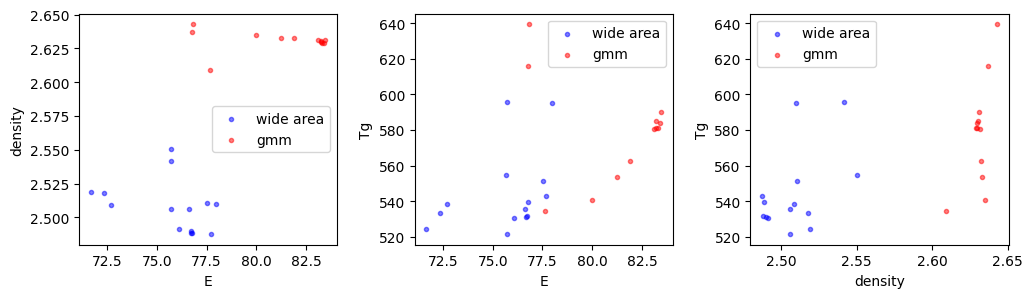

In [6]:
# Draw scatter plots by properties

def_E  = df_opt_def_p['E']
def_d  = df_opt_def_p['density']
def_Tg = df_opt_def_p['Tg']
gmm_E  = df_opt_gmm_p['E']
gmm_d  = df_opt_gmm_p['density']
gmm_Tg = df_opt_gmm_p['Tg']

fig = plt.figure(figsize=(12, 3))

plt.subplot(1,3,1)
plt.scatter(def_E, def_d, c='b', marker = '.', alpha = 0.5, label = 'wide area')
plt.scatter(gmm_E, gmm_d, c='r', marker = '.', alpha = 0.5, label = 'gmm')
plt.xlabel('E'), plt.ylabel('density'), plt.legend()

plt.subplot(1,3,2)
plt.scatter(def_E, def_Tg, c='b', marker = '.', alpha = 0.5, label = 'wide area')
plt.scatter(gmm_E, gmm_Tg, c='r', marker = '.', alpha = 0.5, label = 'gmm')
plt.xlabel('E'), plt.ylabel('Tg'), plt.legend()

plt.subplot(1,3,3)
plt.scatter(def_d, def_Tg, c='b', marker = '.', alpha = 0.5, label = 'wide area')
plt.scatter(gmm_d, gmm_Tg, c='r', marker = '.', alpha = 0.5, label = 'gmm')
plt.xlabel('density'), plt.ylabel('Tg'), plt.legend()

plt.subplots_adjust(wspace=0.3)
plt.show()